In [1]:
import pandas as pd

# STEP 1

# Loading dataset
df = pd.read_csv("blkjckhands.csv")
df = df.drop(columns=["Unnamed: 0"])  # removed useless column

df.head()

# Checking data
df.info()
df.describe()
df.isnull().sum()

# Made a copy of the original file
df.to_csv("blackjack_raw_backup.csv", index=False)


# Dataset with only pre-decision features
df_model = df.copy()

# Define the list of columns we keep
keep_columns = [
    "card1",
    "card2",
    "dealcard1",       # dealer upcard
    "winloss"          # target variable
]

# Filter only these columns
df_model = df_model[keep_columns]

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
)

df_model["is_soft_hand"] = df_model["is_soft_hand"].astype(int)

df_model.shape
df_model.head()
df_model["winloss"].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   PlayerNo     900000 non-null  object
 1   card1        900000 non-null  int64 
 2   card2        900000 non-null  int64 
 3   card3        900000 non-null  int64 
 4   card4        900000 non-null  int64 
 5   card5        900000 non-null  int64 
 6   sumofcards   900000 non-null  int64 
 7   dealcard1    900000 non-null  int64 
 8   dealcard2    900000 non-null  int64 
 9   dealcard3    900000 non-null  int64 
 10  dealcard4    900000 non-null  int64 
 11  dealcard5    900000 non-null  int64 
 12  sumofdeal    900000 non-null  int64 
 13  blkjck       900000 non-null  object
 14  winloss      900000 non-null  object
 15  plybustbeat  900000 non-null  object
 16  dlbustbeat   900000 non-null  object
 17  plwinamt     900000 non-null  int64 
 18  dlwinamt     900000 non-null  int64 
 19  pl

winloss
Loss    429821
Win     385946
Push     84233
Name: count, dtype: int64

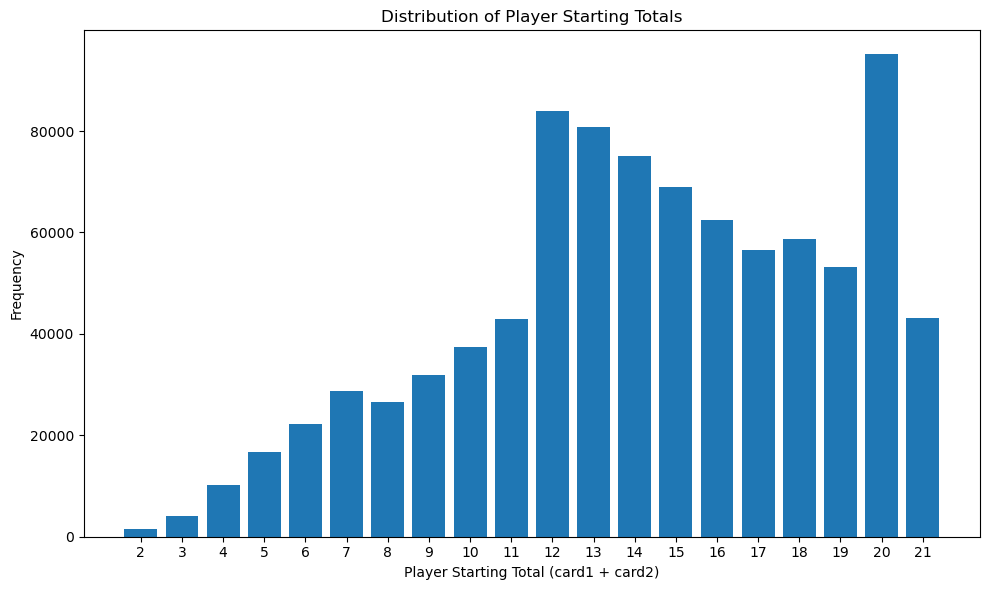

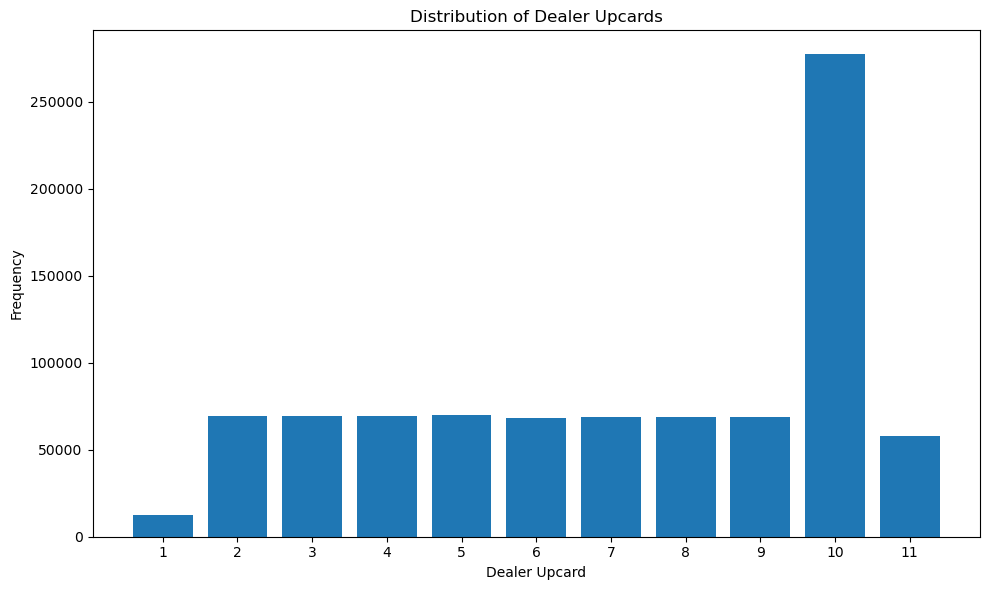

In [2]:
import matplotlib.pyplot as plt

# STEP 2.1 Distribution of player starting totals and dealer upcard

df_model.describe()
df_model["winloss"].value_counts(normalize=True)


# Distribution of player starting totals
player_counts = df_model["player_total_pre"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(player_counts.index.astype(str), player_counts.values)
plt.title("Distribution of Player Starting Totals")
plt.xlabel("Player Starting Total (card1 + card2)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Dealer upcard distribution
dealer_counts = df_model["dealcard1"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(dealer_counts.index.astype(str), dealer_counts.values)
plt.title("Distribution of Dealer Upcards")
plt.xlabel("Dealer Upcard")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


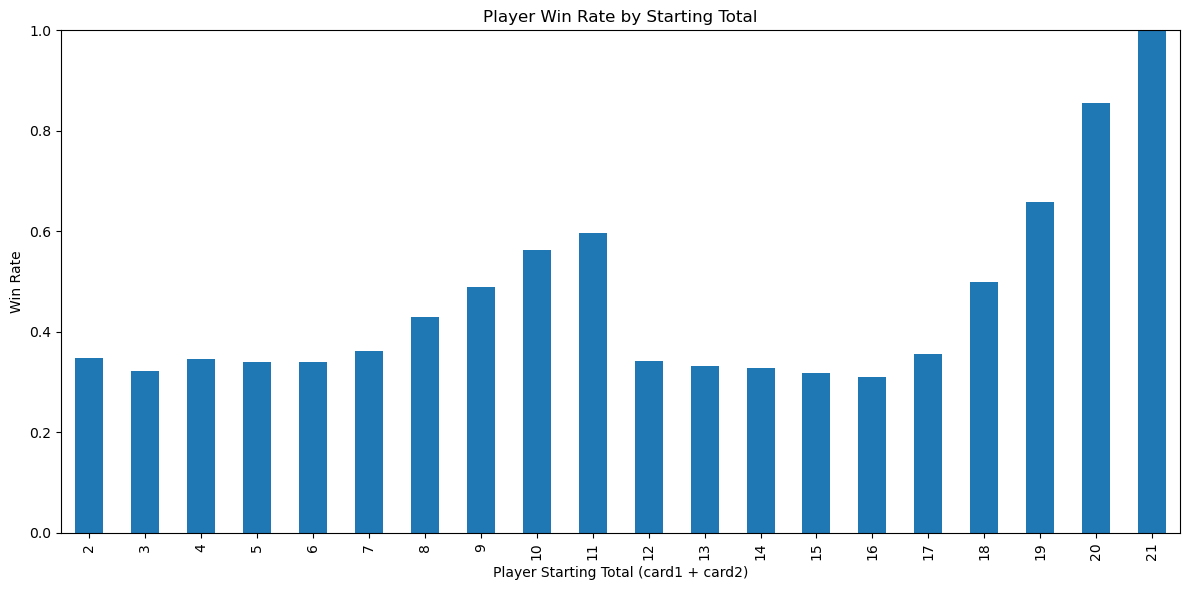

In [3]:
# STEP 2.2 Win rate by player starting total

# RESET df_model completely before doing winloss conversion

df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)


# Convert winloss to numeric: Win = 1, Loss = 0, remove Push

df_model["winloss"] = (
    df_model["winloss"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        "Win": 1,
        "Loss": 0
    })
)

# Remove Push rows
df_model = df_model[df_model["winloss"].isin([0, 1])]

# Ensure integer type
df_model["winloss"] = df_model["winloss"].astype(int)

# Win rate by player starting total plot
win_rates_player = df_model.groupby("player_total_pre")["winloss"].mean()

plt.figure(figsize=(12,6))
win_rates_player.plot(kind="bar")
plt.title("Player Win Rate by Starting Total")
plt.xlabel("Player Starting Total (card1 + card2)")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

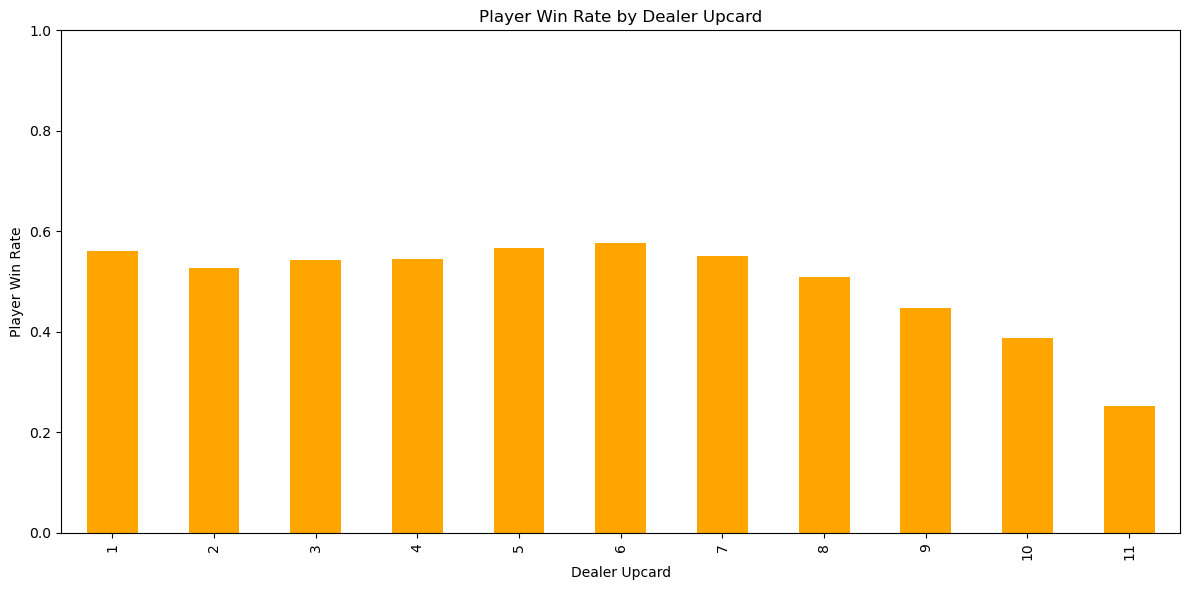

In [4]:
# STEP 2.3 Win rate by dealer upcard

# RESET df_model completely before doing winloss conversion
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)

# Convert winloss to numeric: Win = 1, Loss = 0, remove Push
df_model["winloss"] = (
    df_model["winloss"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        "Win": 1,
        "Loss": 0
    })
)

# Remove Push rows
df_model = df_model[df_model["winloss"].isin([0, 1])]

# Ensure integer type
df_model["winloss"] = df_model["winloss"].astype(int)

# Win rate by dealer upcard plot
win_rates_dealer = df_model.groupby("dealcard1")["winloss"].mean()

plt.figure(figsize=(12,6))
win_rates_dealer.plot(kind="bar", color="orange")
plt.title("Player Win Rate by Dealer Upcard")
plt.xlabel("Dealer Upcard")
plt.ylabel("Player Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


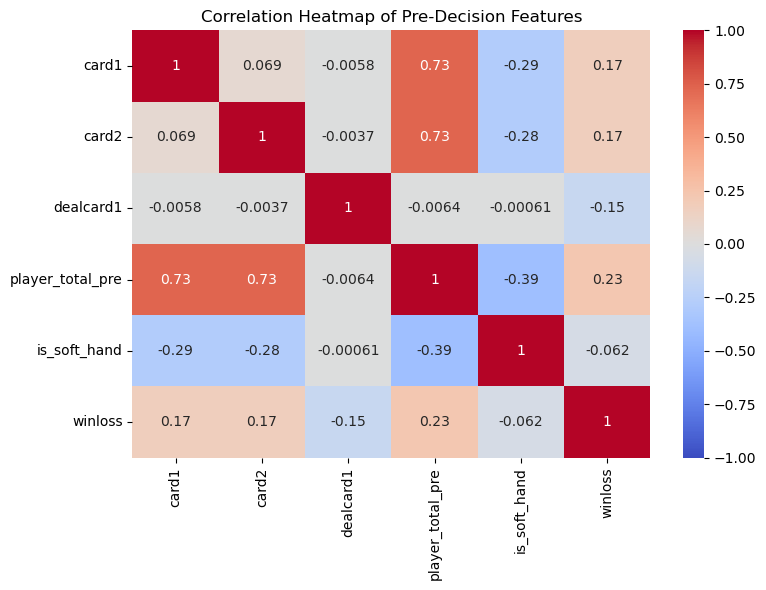

In [5]:
import seaborn as sns

# STEP 2.4 Correlation heatmap
 
# RESET df_model completely before doing winloss conversion
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)

# Convert winloss to numeric (Win = 1, Loss = 0)
df_model["winloss"] = (
    df_model["winloss"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        "Win": 1,
        "Loss": 0
    })
)

# Remove Push rows
df_model = df_model[df_model["winloss"].isin([0, 1])]
df_model["winloss"] = df_model["winloss"].astype(int)

# Correlation heatmap plot 
corr = df_model[["card1", "card2", "dealcard1", "player_total_pre", "is_soft_hand", "winloss"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Pre-Decision Features")
plt.tight_layout()
plt.show()


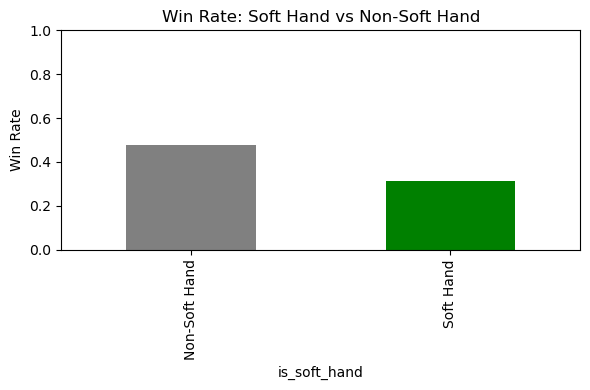

In [6]:
# STEP 2.5 Soft-hand win rate

# RESET df_model completely before doing winloss conversion
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)

# Convert winloss to numeric (Win = 1, Loss = 0)
df_model["winloss"] = (
    df_model["winloss"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        "Win": 1,
        "Loss": 0
    })
)

# Remove Push rows
df_model = df_model[df_model["winloss"].isin([0, 1])]
df_model["winloss"] = df_model["winloss"].astype(int)

# Soft-hand win rate plot
soft_hand_winrates = df_model.groupby("is_soft_hand")["winloss"].mean()

plt.figure(figsize=(6,4))
soft_hand_winrates.plot(kind="bar", color=["gray", "green"])
plt.title("Win Rate: Soft Hand vs Non-Soft Hand")
plt.xticks([0, 1], ["Non-Soft Hand", "Soft Hand"])
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


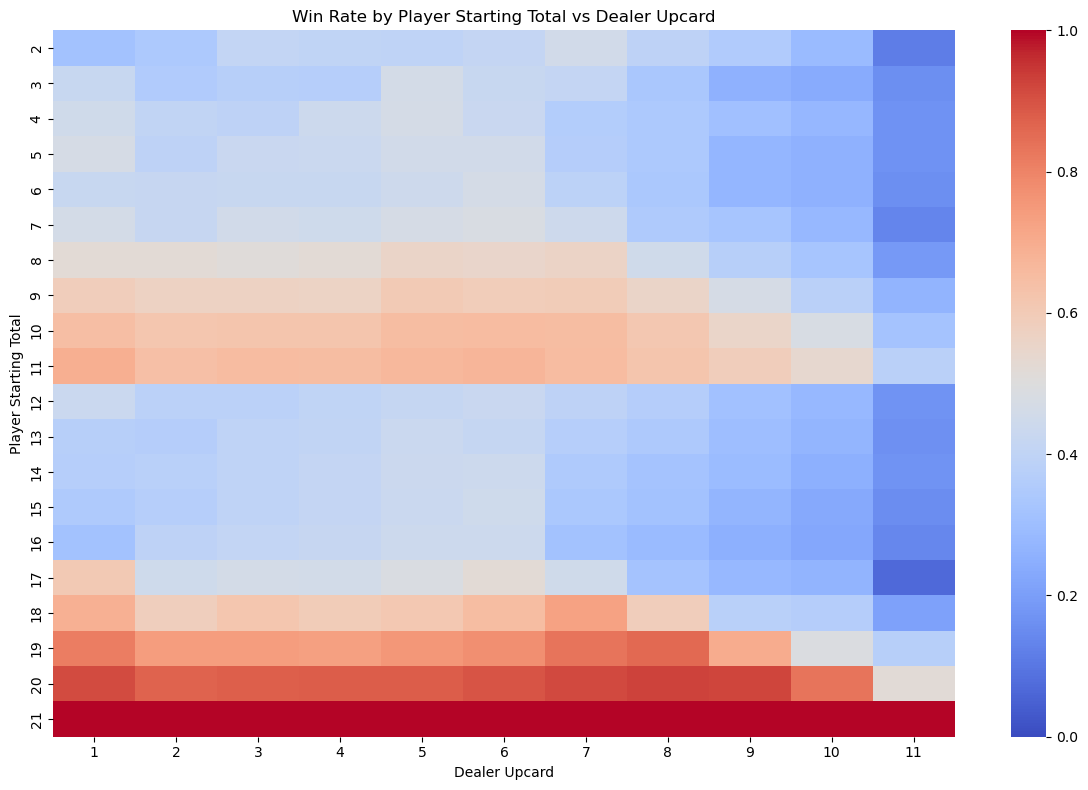

In [7]:
# STEP 2.6 Player win rate by (Player Starting Total and Dealer Upcard)

# RESET df_model completely before doing winloss conversion
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# Player total before hitting
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]

# Soft-hand indicator (Ace = 11 possibility)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)

# Convert winloss to numeric: Win = 1, Loss = 0
df_model["winloss"] = (
    df_model["winloss"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace({
        "Win": 1,
        "Loss": 0
    })
)

# Remove Push rows
df_model = df_model[df_model["winloss"].isin([0, 1])]
df_model["winloss"] = df_model["winloss"].astype(int)

# Win rate heatmap: player total vs dealer upcard

# Create pivot table
heatmap_data = df_model.pivot_table(
    values="winloss",
    index="player_total_pre",
    columns="dealcard1",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=False, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Win Rate by Player Starting Total vs Dealer Upcard")
plt.xlabel("Dealer Upcard")
plt.ylabel("Player Starting Total")
plt.tight_layout()
plt.show()

In [8]:
# STEP 3 Feature Engineering

# RESET df_model
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()

# 1. card1:
#    The player's first card. Used directly as a numeric feature.

# 2. card2:
#    The player's second card. Helps identify combinations and pairs.

# 3. dealcard1:
#     The dealer's visible card. One of the strongest predictors.

# 4. winloss:
#     The cleaned target variable (1 = win, 0 = loss).
#     Push outcomes are removed so the model learns only win/loss classification.


# Basic features

# 5. Player starting total
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]
# player_total_pre:
#   The player's starting total. This is the most important predictor of winning,
#   because higher starting totals are much more likely to win.


# 6. Soft hand indicator
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1))
    & (df_model["player_total_pre"] <= 11)
).astype(int)
# is_soft_hand:
#   Indicates whether the hand has an Ace counted as 11.
#   Soft hands behave differently (safer to hit), so they have different win patterns.


# Additional engineered features

# 7. Ace indicator
df_model["has_ace"] = ((df_model["card1"] == 1) | (df_model["card2"] == 1)).astype(int)
# has_ace:
#   Shows if the player has any Ace at all.
#   Even if it's not a soft hand, having an Ace affects flexibility and win odds.


# 8. Pair indicator
df_model["is_pair"] = (df_model["card1"] == df_model["card2"]).astype(int)
# is_pair:
#   Indicates if the two starting cards are a pair.
#   Pairs influence strength patterns and are relevant for split-based decision zones
#   (even though you are not modelling splits).


# 9. Dealer strength category
def dealer_strength(card):
    if card in [2, 3, 4, 5, 6]:
        return "weak"
    elif card in [7, 8, 9]:
        return "neutral"
    else:
        return "strong"

df_model["dealer_strength"] = df_model["dealcard1"].apply(dealer_strength)
# dealer_strength:
#   Groups dealer upcards into strategic difficulty levels.
#   Dealer 2-6 are weak, 7–9 are neutral, 10/Ace are strong.
#   This is exactly how blackjack strategy classifies dealer danger.


# 10. Player risk zone
def risk_zone(total):
    if total <= 11:
        return "low"
    elif 12 <= total <= 16:
        return "medium"
    else:
        return "high"

df_model["player_risk_zone"] = df_model["player_total_pre"].apply(risk_zone)
# player_risk_zone:
#   Categorizes the player’s total into risk groups.
#   12-16 is the "danger zone" where losing is most common.
#   Totals >= 17 are strong; totals <= 11 have no bust risk.


# 11. Advantage metric (numeric)
df_model["advantage_metric"] = df_model["player_total_pre"] - df_model["dealcard1"]
# advantage_metric:
#   Numerical "strength difference" between player and dealer.
#   Positive values mean the player starts ahead, negative means behind.
#   Values vary from -8 up to +19.
#   This helps the model understand relative strength more smoothly than categories.


# Clean winloss (Win = 1, Loss = 0), remove Push
df_model["winloss"] = (
    df_model["winloss"].astype(str).str.strip().str.capitalize()
    .replace({"Win": 1, "Loss": 0})
)

df_model = df_model[df_model["winloss"].isin([0, 1])]
df_model["winloss"] = df_model["winloss"].astype(int)

df_model.sample(5)


,card1,card2,dealcard1,winloss,player_total_pre,is_soft_hand,has_ace,is_pair,dealer_strength,player_risk_zone,advantage_metric
626263,4,1,9,1,5,1,1,0,neutral,low,-4
893665,7,4,6,1,11,0,0,0,weak,low,5
355781,10,2,4,1,12,0,0,0,weak,medium,8
367144,6,1,5,0,7,1,1,0,weak,low,2
390052,10,10,10,1,20,0,0,1,strong,high,10


In [9]:
# STEP 4 Model development & tuning

# STEP 4.1 RESET df_model for modeling
# We rebuild the dataset from scratch to avoid data leakage and ensure consistent preprocessing
df_model = df[["card1", "card2", "dealcard1", "winloss"]].copy()


# Basic features

# 1. Player starting total (sum of first two cards)
df_model["player_total_pre"] = df_model["card1"] + df_model["card2"]
# This feature is one of the strongest predictors because higher totals tend to win more often.


# 2. Soft-hand indicator (Ace counted as 11)
df_model["is_soft_hand"] = (
    ((df_model["card1"] == 1) | (df_model["card2"] == 1)) &
    (df_model["player_total_pre"] <= 11)
).astype(int)
# Soft hands allow safer hits because they cannot bust immediately.


# 3. Ace indicator (ANY Ace in the hand)
df_model["has_ace"] = ((df_model["card1"] == 1) | (df_model["card2"] == 1)).astype(int)
# Shows if the player has an Ace at all (soft or hard).
# Aces change strategy significantly.


# 4. Pair indicator (card1 == card2)
df_model["is_pair"] = (df_model["card1"] == df_model["card2"]).astype(int)
# Indicates whether the hand consists of two identical cards.
# Useful for capturing patterns where pairs have distinct win/loss behavior.


# 5. Dealer strength category
def dealer_strength(card):
    if card in [2,3,4,5,6]:
        return "weak"      # Dealer weak cards – high chance dealer busts
    elif card in [7,8,9]:
        return "neutral"   # Middle strength
    else:
        return "strong"    # Dealer 10 or Ace – worst for the player

df_model["dealer_strength"] = df_model["dealcard1"].apply(dealer_strength)
# A categorical feature reflecting how dangerous the dealer's upcard is.


# 6. Player risk zone
def risk_zone(total):
    if total <= 11:
        return "low"       # Cannot bust, safe totals
    elif 12 <= total <= 16:
        return "medium"    # "Danger zone": highest losing rate
    else:
        return "high"      # Strong totals: good chance to stand and win

df_model["player_risk_zone"] = df_model["player_total_pre"].apply(risk_zone)
# Converts raw totals into strategic buckets that models can understand more easily.


# 7. Advantage metric
df_model["advantage_metric"] = df_model["player_total_pre"] - df_model["dealcard1"]
# A numerical measure of how strong the player's start is compared to the dealer.
# Positive = good for player, negative = good for dealer.


# Clean winloss -> numeric binary target
df_model["winloss"] = (
    df_model["winloss"].astype(str).str.strip().str.capitalize()
    .replace({"Win": 1, "Loss": 0})
)
# Convert textual outcomes into numeric labels.
# Pushes will not be included (removed below).

df_model = df_model[df_model["winloss"].isin([0, 1])]
# Remove rows where winloss was "Push" or unknown.

df_model["winloss"] = df_model["winloss"].astype(int)
# Final target: 1 = win, 0 = loss


In [10]:
# STEP 4.2 Encode categorical features

# One-hot encode dealer_strength and player_risk_zone
df_encoded = pd.get_dummies(
    df_model,
    columns=["dealer_strength", "player_risk_zone"],
    drop_first=True  # removes the first category to avoid creating duplicate information
)

In [11]:
from sklearn.model_selection import train_test_split

# STEP 4.3 Create train/test split

# X = all features used for prediction
X = df_encoded.drop("winloss", axis=1)

# y = target variable we want to predict (1 = win, 0 = loss)
y = df_encoded["winloss"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% of the data is kept for testing
    random_state=42,    # ensures the split is the same every time (reproducibility)
    stratify=y          # keeps the win/loss ratio the same in both sets
)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# STEP 4.4 Logistic regression

# Create the logistic regression model
# max_iter=1000 allows the model enough iterations to converge
log_model = LogisticRegression(max_iter=1000)

# Train (fit) the model on the training data
log_model.fit(X_train, y_train)

# Predict win/loss on the test set
y_pred_log = log_model.predict(X_test)

# Print accuracy on unseen data
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

# Show precision, recall, f1-score for both win (1) and loss (0)
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.6747980435662012
              precision    recall  f1-score   support

           0       0.67      0.76      0.71     85965
           1       0.68      0.58      0.63     77189

    accuracy                           0.67    163154
   macro avg       0.68      0.67      0.67    163154
weighted avg       0.68      0.67      0.67    163154



In [13]:
from sklearn.tree import DecisionTreeClassifier

# STEP 4.5 Decision tree classifier

# Create a decision tree model
# max_depth=5 limits how many levels the tree can grow (prevents overfitting)
# random_state=42 ensures the same tree structure is produced every time
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model on the training data
tree_model.fit(X_train, y_train)

# Predict win/loss on the test set
y_pred_tree = tree_model.predict(X_test)

# Print accuracy on unseen test data
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Decision Tree Accuracy: 0.6901761525920296


In [14]:
from sklearn.ensemble import RandomForestClassifier

# STEP 4.6 Random forest classifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,   # number of decision trees in the forest
    max_depth=None,    # allow trees to grow fully (no depth limit)
    random_state=42,   # ensures reproducible results
    n_jobs=-1          # use all CPU cores for faster training
)

# Train the model on the training data (each tree sees a random subset)
rf_model.fit(X_train, y_train)

# Predict win/loss on the test data using the ensemble of trees
y_pred_rf = rf_model.predict(X_test)

# Print accuracy on unseen test data
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.6950488495531829


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# STEP 4.7 Hyperparameter tuning (randomized search)

# Use only a small sample for tuning
# This makes tuning MUCH faster while still giving good results
df_tune = df_encoded.sample(n=50000, random_state=42)

# Split features and target for tuning
X_tune = df_tune.drop("winloss", axis=1)
y_tune = df_tune["winloss"]

# Create train/test split for tuning
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tune, y_tune,
    test_size=0.2,       # use 20% for testing
    random_state=42,     # reproducibility
    stratify=y_tune      # keeps win/loss ratio balanced
)

# Randomized search parameter distributions
param_dist = {
    "n_estimators": randint(100, 300),   # choose a random number of trees between 100 and 300
    "max_depth": [None, 5, 10],          # try fully grown trees or limited depth
    "min_samples_split": [2, 5, 10]      # minimum samples needed to split a node
}

# RandomizedSearchCV tries random combinations of parameters instead of all combinations
rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),  # base model to optimize
    param_distributions=param_dist,           # parameter search space
    n_iter=10,                                # try 10 random combinations (much faster than GridSearch)
    cv=3,                                     # 3-fold cross validation
    n_jobs=-1,                                # use all CPU cores
    scoring="accuracy",                       # evaluate models using accuracy score
    random_state=42                           # reproducibility of the random choices
)

# Run the tuning on the tuning training set
rand.fit(X_train_t, y_train_t)

# Print the best parameters found by randomized search
print("Best parameters:", rand.best_params_)

# Print the best cross-validation score during tuning
print("Best CV score:", rand.best_score_)

# The best model from the search
best_rf = rand.best_estimator_

# Evaluate the tuned model on the tuning test set
print("Test accuracy:", accuracy_score(y_test, best_rf.predict(X_test)))


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 120}
Best CV score: 0.6938501383638536
Test accuracy: 0.6919474851980337


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# STEP 4.8 k-Nearest Neighbors classifier

# Create the k-NN model
# n_neighbors=7 balanced choice for large dataset
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn_model.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn_model.predict(X_test)

# Accuracy
print("k-NN Accuracy:", accuracy_score(y_test, y_pred_knn))


k-NN Accuracy: 0.6567169667921106


In [17]:
import numpy as np

# STEP 4.9 Feature importance

# Extract importance scores for each feature from the tuned Random Forest
feature_importances = best_rf.feature_importances_

# Sort feature positions from most important -> least important
sorted_positions = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

# Print each feature in order of importance
for position in sorted_positions:
    feature_name = X.columns[position]
    importance_value = feature_importances[position]
    print(f"{feature_name}: {importance_value:.4f}")


Feature ranking:
player_total_pre: 0.2824
advantage_metric: 0.2273
player_risk_zone_medium: 0.1120
card2: 0.0957
card1: 0.0942
dealcard1: 0.0875
dealer_strength_strong: 0.0287
dealer_strength_weak: 0.0239
is_pair: 0.0220
player_risk_zone_low: 0.0143
is_soft_hand: 0.0063
has_ace: 0.0058


In [18]:
!pip install lightgbm

In [19]:
from lightgbm import LGBMClassifier

# STEP 4.10 LightGBM

# Create a LightGBM model
lgb_model = LGBMClassifier(
    n_estimators=300,  # number of boosting rounds (trees)
    learning_rate=0.05,  # how fast the model learns (small = more accurate)
    max_depth=-1,        # -1 = no depth limit (tree can grow as needed)
    random_state=42      # reproducible results
)

# Train the model on the training data
lgb_model.fit(X_train, y_train)

# Predict win/loss on the test set
y_pred_lgb = lgb_model.predict(X_test)

# Print the model accuracy
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 308757, number of negative: 343856
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 101
[LightGBM] [Info] Number of data points in the train set: 652613, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473109 -> initscore=-0.107668
[LightGBM] [Info] Start training from score -0.107668
LightGBM Accuracy: 0.6950917538031554


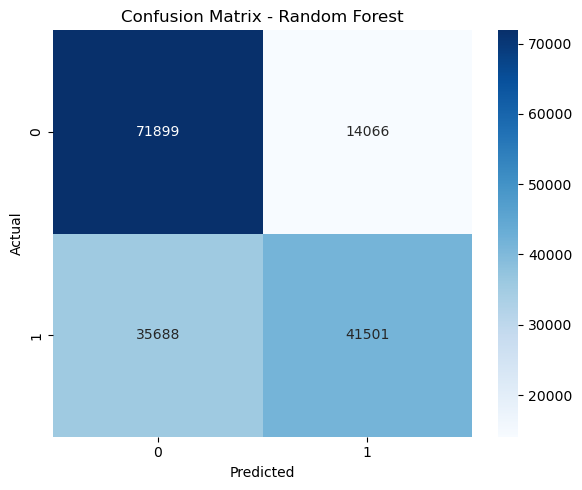

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


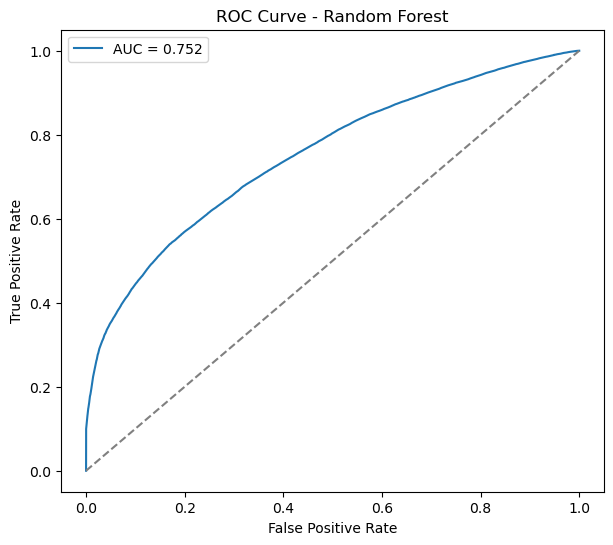

In [25]:
from sklearn.metrics import roc_curve, auc

# Probability of WIN from Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


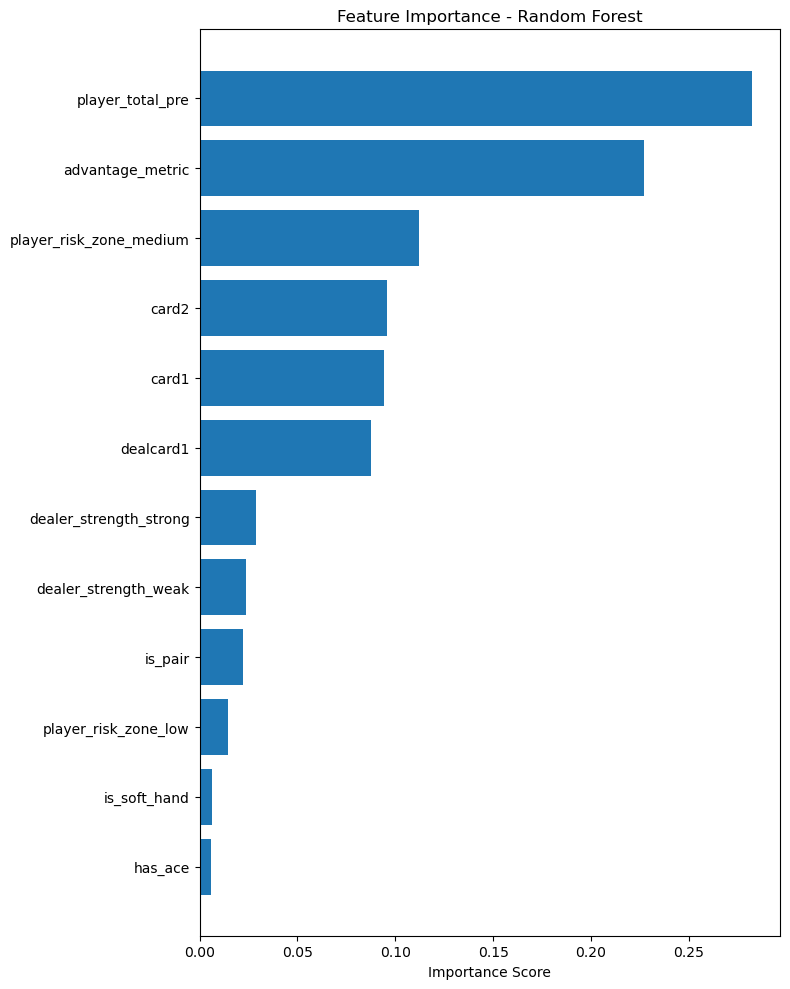

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importances from tuned Random Forest
importances = best_rf.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8,10))
plt.barh(np.array(X.columns)[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
